# Задача 4. Реализация поиска кратчайших путей

**ФИО:** Непомнящий Матвей Тимофеевич  
**ИСУ:** 507189  
**Группа:** S4102


## Задача

Везде считаем, что вершины графа занумерованы подряд с **нуля**. Про наличие отрицательных циклов заранее неизвестно.

Реализуем и тестируем:
1. **Bellman-Ford** из одной вершины (массив расстояний, `inf` если пути нет).
2. **Multi-source Bellman-Ford** (список пар `(source, distances[])`).
3. **Floyd-Warshall** и **транзитивное замыкание** для всех пар.
4. Эксперименты на SuiteSparse и случайных графах (+3).
5. Push/pull для операций в BF (+2).


## Импорты и загрузка графов

Граф — матрица смежности $A$ (FP64). Ниже утилиты, алгоритмы, тесты и замеры.


In [116]:
%matplotlib inline

import matplotlib as mpl
mpl.rcParams["figure.dpi"] = 100

import graphblas as gb
gb.init("suitesparse", blocking=False)

from graphblas import Matrix, Vector, dtypes, binary, semiring
from graphblas.io import mmread
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import time
import urllib.request
import tarfile


Чтение MTX и сборка графа из списка рёбер: `load_graph`, `to_weighted_directed`, `build_graph`, `build_complete_directed`.


In [ ]:
def load_graph(path: str) -> Matrix:
    return mmread(path)


def to_weighted_directed(A: Matrix) -> Matrix:
    result = A.dup(dtype=dtypes.FP64)
    result << gb.select.offdiag(result)
    return result


def build_graph(rows, cols, weights, n) -> Matrix:
    return Matrix.from_coo(rows, cols, weights, nrows=n, ncols=n, dtype=dtypes.FP64)


def build_complete_directed(n: int, weight: float = 1.0) -> Matrix:
    rows, cols, weights = [], [], []
    for i in range(n):
        for j in range(n):
            if i != j:
                rows.append(i)
                cols.append(j)
                weights.append(weight)
    return Matrix.from_coo(rows, cols, weights, nrows=n, ncols=n, dtype=dtypes.FP64)


Загрузка графов SuiteSparse: скачивание `.tar.gz` в `../data/suitesparse`, чтение `.mtx`.


In [ ]:
DOWNLOAD_DIR = "../data/suitesparse"
BASE_URL = "https://suitesparse-collection-website.herokuapp.com/MM"


def download_graph(group: str, name: str) -> str:
    graph_dir = os.path.join(DOWNLOAD_DIR, name)
    mtx_path = os.path.join(graph_dir, f"{name}.mtx")
    if os.path.exists(mtx_path):
        return mtx_path

    os.makedirs(DOWNLOAD_DIR, exist_ok=True)
    url = f"{BASE_URL}/{group}/{name}.tar.gz"
    tar_path = os.path.join(DOWNLOAD_DIR, f"{name}.tar.gz")

    print(f"  Downloading {group}/{name} ...")
    urllib.request.urlretrieve(url, tar_path)

    with tarfile.open(tar_path, "r:gz") as tf:
        tf.extractall(DOWNLOAD_DIR)
    os.remove(tar_path)

    if not os.path.exists(mtx_path):
        for root, dirs, files in os.walk(graph_dir):
            for f in files:
                if f.endswith(".mtx"):
                    return os.path.join(root, f)
    return mtx_path


def load_suitesparse_weighted(group: str, name: str) -> Matrix:
    mtx_path = download_graph(group, name)
    return to_weighted_directed(mmread(mtx_path))


Случайный directed-граф и локальные MTX из `lab_2/graphs_for_test`.


In [ ]:
def generate_random_weighted_graph(n: int, density: float, seed: int = 42) -> Matrix:
    from scipy.sparse import random as sp_random
    rng = np.random.default_rng(seed)
    sp = sp_random(n, n, density=density, format="coo", random_state=rng,
                   data_rvs=lambda s: rng.uniform(0.1, 10.0, size=s))
    rows, cols, data = sp.row, sp.col, sp.data
    mask = rows != cols
    r, c, w = rows[mask], cols[mask], data[mask]
    if len(r) == 0:
        return Matrix(dtypes.FP64, nrows=n, ncols=n)
    return Matrix.from_coo(r.tolist(), c.tolist(), w.tolist(), nrows=n, ncols=n, dtype=dtypes.FP64)


GRAPH_ROOT = os.path.abspath(os.path.join("..", "lab_2", "graphs_for_test"))


def load_mtx_weighted(rel_path: str) -> Matrix:
    path = os.path.join(GRAPH_ROOT, *rel_path.split("/"))
    return to_weighted_directed(load_graph(path))


## Задание 1. Bellman-Ford (single-source)

`bellman_ford`: расстояния из одной вершины, релаксация `d.vxm(A, min_plus)`, до $N-1$ итераций, проверка отрицательного цикла.


In [118]:
def bellman_ford(A: Matrix, source: int) -> list:
    """Кратчайшие пути из source. Недостижимые / отрицательный цикл: inf."""
    n = A.nrows
    d = Vector(dtypes.FP64, size=n)
    d[source] = 0.0

    for _ in range(n - 1):
        d_old = d.dup()
        # pull: d = min(d, d @ A) в min-plus
        d(binary.min) << d.vxm(A, semiring.min_plus)
        if d.isequal(d_old):
            break

    d_before_check = d.dup()
    d(binary.min) << d.vxm(A, semiring.min_plus)

    if not d.isequal(d_before_check):
        changed = d.ewise_mult(d_before_check, op=binary.isne).new()
        neg_cycle_vertices = Vector(dtypes.BOOL, size=n)
        for idx, val in zip(*changed.to_coo()):
            if val:
                neg_cycle_vertices[idx] = True

        for _ in range(n - 1):
            old_neg = neg_cycle_vertices.dup()
            propagated = neg_cycle_vertices.vxm(A.apply(gb.unary.one).new(dtype=dtypes.BOOL), semiring.lor_land).new()
            neg_cycle_vertices(binary.lor) << propagated
            if neg_cycle_vertices.isequal(old_neg):
                break

        d_dense = d.to_dense(fill_value=float('inf'))
        neg_dense = neg_cycle_vertices.to_dense(fill_value=False)
        result = []
        for i in range(n):
            if neg_dense[i]:
                result.append(float('inf'))
            else:
                result.append(float(d_dense[i]))
        return result

    d_dense = d.to_dense(fill_value=float('inf'))
    return [float(x) for x in d_dense]


## Задание 2. Multi-source Bellman-Ford

`bellman_ford_multi`: матрица $D$ $|S|\times N$, шаг `D.mxm(A, min_plus)`, на выходе список `(source, distances[])`.


In [119]:
def bellman_ford_multi(A: Matrix, sources: list) -> list:
    """Кратчайшие пути из нескольких источников. Returns: [(source, distances)]."""
    n = A.nrows
    k = len(sources)
    D = Matrix(dtypes.FP64, nrows=k, ncols=n)
    for i, s in enumerate(sources):
        D[i, s] = 0.0

    for _ in range(n - 1):
        D_old = D.dup()
        D(binary.min) << D.mxm(A, semiring.min_plus)
        if D.isequal(D_old):
            break

    D_before = D.dup()
    D(binary.min) << D.mxm(A, semiring.min_plus)

    has_neg_cycle = not D.isequal(D_before)

    neg_mask = None
    if has_neg_cycle:
        changed = D.ewise_mult(D_before, op=binary.isne).new()
        neg_mask = changed.apply(gb.unary.identity).new(dtype=dtypes.BOOL)

        A_bool = A.apply(gb.unary.one).new(dtype=dtypes.BOOL)
        for _ in range(n - 1):
            old_neg = neg_mask.dup()
            propagated = neg_mask.mxm(A_bool, semiring.lor_land).new()
            neg_mask(binary.lor) << propagated
            if neg_mask.isequal(old_neg):
                break

    result = []
    for i, s in enumerate(sources):
        row_vec = D[i, :].new()
        d_dense = row_vec.to_dense(fill_value=float('inf'))
        distances = [float(x) for x in d_dense]

        if neg_mask is not None:
            neg_row = neg_mask[i, :].new()
            neg_dense = neg_row.to_dense(fill_value=False)
            for j in range(n):
                if neg_dense[j]:
                    distances[j] = float('inf')

        result.append((s, distances))

    return result


## Задание 3. Floyd-Warshall (all-pairs)

`floyd_warshall`: цикл по $k$ с outer product, сбор `(vertex, distances[])`, обработка отрицательных циклов.


In [120]:
def floyd_warshall(A: Matrix) -> list:
    """All-pairs (Floyd-Warshall). Returns: [(vertex, distances)]."""
    n = A.nrows
    D = A.dup()
    for i in range(n):
        D[i, i] = 0.0

    for k in range(n):
        col_k = D[:, k].new()
        row_k = D[k, :].new()
        outer = col_k.outer(row_k, op=binary.plus).new()
        D(binary.min) << outer

    neg_diag = False
    diag = D.diag()
    diag_indices, diag_values = diag.to_coo()
    for val in diag_values:
        if val < 0:
            neg_diag = True
            break

    neg_cycle_nodes = set()
    if neg_diag:
        for idx, val in zip(diag_indices, diag_values):
            if val < 0:
                neg_cycle_nodes.add(int(idx))

    result = []
    for i in range(n):
        row = D[i, :].new()
        d_dense = row.to_dense(fill_value=float('inf'))
        distances = [float(x) for x in d_dense]

        if neg_cycle_nodes:
            for j in range(n):
                for m in neg_cycle_nodes:
                    i_to_m = D.get(i, m, default=None)
                    m_to_j = D.get(m, j, default=None)
                    if i_to_m is not None and m_to_j is not None:
                        distances[j] = float('inf')
                        break

        result.append((i, distances))

    return result


## Задание 4. Транзитивное замыкание (all-pairs)

`transitive_closure_apsp`: repeated squaring `D.mxm(D, min_plus)`, формат результата как у FW.


In [121]:
def transitive_closure_apsp(A: Matrix) -> list:
    """All-pairs через repeated squaring. Returns: [(vertex, distances)]."""
    n = A.nrows
    D = A.dup()
    for i in range(n):
        D[i, i] = 0.0

    for _ in range(int(np.ceil(np.log2(n))) + 1):
        D_old = D.dup()
        D(binary.min) << D.mxm(D, semiring.min_plus)
        if D.isequal(D_old):
            break

    neg_cycle_nodes = set()
    diag = D.diag()
    for idx, val in zip(*diag.to_coo()):
        if val < 0:
            neg_cycle_nodes.add(int(idx))

    result = []
    for i in range(n):
        row = D[i, :].new()
        d_dense = row.to_dense(fill_value=float('inf'))
        distances = [float(x) for x in d_dense]

        if neg_cycle_nodes:
            for j in range(n):
                for m in neg_cycle_nodes:
                    i_to_m = D.get(i, m, default=None)
                    m_to_j = D.get(m, j, default=None)
                    if i_to_m is not None and m_to_j is not None:
                        distances[j] = float('inf')
                        break

        result.append((i, distances))

    return result


## Задание 5. Тесты корректности

8 графов; сверяем BF, multi-BF, FW и TC через `assert_distances_equal`.


In [122]:
INF = float('inf')


def apsp_to_dict(apsp_result: list) -> dict:
    return {v: dists for v, dists in apsp_result}


def assert_distances_equal(actual, expected, label=""):
    assert len(actual) == len(expected), (
        f"{label}: len mismatch: {len(actual)} != {len(expected)}"
    )
    for i, (a, e) in enumerate(zip(actual, expected)):
        if e == INF:
            assert a == INF, f"{label}: vertex {i}: expected inf, got {a}"
        else:
            assert abs(a - e) < 1e-9, f"{label}: vertex {i}: expected {e}, got {a}"


### Тест 1

Цепочка 0→1→2→3, веса 2, 3, 5.


In [123]:
G1 = build_graph([0, 1, 2], [1, 2, 3], [2.0, 3.0, 5.0], n=4)

expected_bf_0 = [0.0, 2.0, 5.0, 10.0]
expected_bf_2 = [INF, INF, 0.0, 5.0]
print("из 0 (BF):", bellman_ford(G1, 0))
print("из 2 (BF):", bellman_ford(G1, 2))

assert_distances_equal(bellman_ford(G1, 0), expected_bf_0, "BF from 0")
assert_distances_equal(bellman_ford(G1, 2), expected_bf_2, "BF from 2")

multi_dict = {s: d for s, d in bellman_ford_multi(G1, [0, 2])}
assert_distances_equal(multi_dict[0], expected_bf_0, "Multi from 0")
assert_distances_equal(apsp_to_dict(floyd_warshall(G1))[0], expected_bf_0, "FW from 0")

print("Тест 1 (цепочка): OK")


из 0 (BF): [0.0, 2.0, 5.0, 10.0]
из 2 (BF): [inf, inf, 0.0, 5.0]
Тест 1 (цепочка): OK


### Тест 2

Две компоненты, недостижимые вершины.


In [124]:
G2 = build_graph([0, 1, 3], [1, 2, 4], [1.0, 2.0, 3.0], n=5)

expected_0 = [0.0, 1.0, 3.0, INF, INF]
expected_3 = [INF, INF, INF, 0.0, 3.0]
assert_distances_equal(bellman_ford(G2, 0), expected_0, "BF from 0")
assert_distances_equal(bellman_ford(G2, 3), expected_3, "BF from 3")

multi_dict = {s: d for s, d in bellman_ford_multi(G2, [0, 3])}
assert_distances_equal(multi_dict[0], expected_0, "Multi from 0")
assert_distances_equal(multi_dict[3], expected_3, "Multi from 3")

fw = apsp_to_dict(floyd_warshall(G2))
assert_distances_equal(fw[0], expected_0, "FW from 0")
assert_distances_equal(fw[3], expected_3, "FW from 3")

print("Тест 2: OK")


Тест 2: OK


### Тест 3

Отрицательное ребро без цикла.


In [125]:
G3 = build_graph([0, 0, 1, 2], [1, 2, 2, 3], [4.0, 5.0, -3.0, 4.0], n=4)
expected = [0.0, 4.0, 1.0, 5.0]

assert_distances_equal(bellman_ford(G3, 0), expected, "BF")
assert_distances_equal(bellman_ford_multi(G3, [0])[0][1], expected, "Multi")
assert_distances_equal(apsp_to_dict(floyd_warshall(G3))[0], expected, "FW")
assert_distances_equal(apsp_to_dict(transitive_closure_apsp(G3))[0], expected, "TC")

print("Тест 3: OK")


Тест 3: OK


### Тест 4

Отрицательный цикл.


In [126]:
G4 = build_graph([0, 1, 2, 0], [1, 2, 0, 3], [1.0, 2.0, -4.0, 10.0], n=4)
expected_neg = [INF, INF, INF, INF]

assert_distances_equal(bellman_ford(G4, 0), expected_neg, "BF")
assert_distances_equal(bellman_ford_multi(G4, [0])[0][1], expected_neg, "Multi")
assert_distances_equal(apsp_to_dict(floyd_warshall(G4))[0], expected_neg, "FW")
assert_distances_equal(apsp_to_dict(transitive_closure_apsp(G4))[0], expected_neg, "TC")

print("Тест 4: OK")


Тест 4: OK


### Тест 5

Полный $K_4$, вес 1.


In [127]:
G5 = build_complete_directed(4)

for src in range(4):
    expected = [1.0] * 4
    expected[src] = 0.0
    assert_distances_equal(bellman_ford(G5, src), expected, f"BF from {src}")

for src, dists in bellman_ford_multi(G5, list(range(4))):
    expected = [1.0] * 4
    expected[src] = 0.0
    assert_distances_equal(dists, expected, f"Multi from {src}")

fw = apsp_to_dict(floyd_warshall(G5))
tc = apsp_to_dict(transitive_closure_apsp(G5))
for src in range(4):
    expected = [1.0] * 4
    expected[src] = 0.0
    assert_distances_equal(fw[src], expected, f"FW from {src}")
    assert_distances_equal(tc[src], expected, f"TC from {src}")

print("Тест 5: OK")


Тест 5: OK


### Тест 6

Граф из практики, 7 вершин.


In [128]:
G6 = build_graph(
    [3, 0, 3, 5, 6, 0, 6, 1, 6, 2, 4, 1],
    [0, 1, 2, 2, 2, 3, 3, 4, 4, 5, 5, 6],
    [3.0, 2.0, 3.0, 1.0, 5.0, 3.0, 7.0, 8.0, 3.0, 1.0, 7.0, 4.0],
    n=7,
)

bf_results = {src: bellman_ford(G6, src) for src in range(7)}
multi_dict = {s: d for s, d in bellman_ford_multi(G6, list(range(7)))}
fw = apsp_to_dict(floyd_warshall(G6))
tc = apsp_to_dict(transitive_closure_apsp(G6))

for src in range(7):
    assert_distances_equal(multi_dict[src], bf_results[src], f"Multi vs BF {src}")
    assert_distances_equal(fw[src], bf_results[src], f"FW vs BF {src}")
    assert_distances_equal(tc[src], bf_results[src], f"TC vs BF {src}")

print("Тест 6: OK")
print(f"  Расстояния из 1: {bf_results[1]}")


Тест 6: OK
  Расстояния из 1: [14.0, 0.0, 9.0, 11.0, 7.0, 10.0, 4.0]


### Тест 7

Цикл не затрагивает все вершины.


In [129]:
G7 = build_graph([0, 1, 2, 0], [1, 2, 0, 3], [1.0, 1.0, -3.0, 5.0], n=5)

expected_from_0 = [INF, INF, INF, INF, INF]
expected_from_4 = [INF, INF, INF, INF, 0.0]
assert_distances_equal(bellman_ford(G7, 0), expected_from_0, "BF from 0")
assert_distances_equal(bellman_ford(G7, 4), expected_from_4, "BF from 4")

multi_dict = {s: d for s, d in bellman_ford_multi(G7, [0, 4])}
assert_distances_equal(multi_dict[0], expected_from_0, "Multi from 0")
assert_distances_equal(multi_dict[4], expected_from_4, "Multi from 4")

print("Тест 7: OK")


Тест 7: OK


### Тест 8

Граф `email`, 1133 вершины.


In [130]:
email_g = load_mtx_weighted("email/email.mtx")
n_e = email_g.nrows

multi_e = {s: d for s, d in bellman_ford_multi(email_g, list(range(n_e)))}
fw_e = apsp_to_dict(floyd_warshall(email_g))
tc_e = apsp_to_dict(transitive_closure_apsp(email_g))

for src in [0, 1, n_e // 2, n_e - 1]:
    assert_distances_equal(bellman_ford(email_g, src), fw_e[src], f"email BF vs FW {src}")

for src in range(n_e):
    assert_distances_equal(multi_e[src], fw_e[src], f"email Multi vs FW {src}")
    assert_distances_equal(tc_e[src], fw_e[src], f"email TC vs FW {src}")

print(f"Тест 8 (email, {n_e} вершин): OK")


Тест 8 (email, 1133 вершин): OK


## Задание 6 (+3 балла). Эксперименты

Замеры на SuiteSparse (подграфы n≤600 для всех алгоритмов) и случайных графах: размер, плотность, crossover.


Функции `_time_call`, `extract_subgraph` и `benchmark_sssp`: multi-BF всегда, FW/TC при n≤600.


In [131]:
MAX_APSP_N = 600  # FW/TC только для n <= 600 (иначе минуты ожидания)


def _time_call(fn, *args, n_runs=1):
    elapsed = []
    for _ in range(n_runs):
        start = time.perf_counter()
        fn(*args)
        elapsed.append(time.perf_counter() - start)
    return {"mean_s": float(np.mean(elapsed)), "std_s": float(np.std(elapsed))}


def extract_subgraph(A: Matrix, n_sub: int, start: int = 0) -> Matrix:
    """Связный индуцированный подграф из n_sub вершин (BFS от start)."""
    n_sub = min(n_sub, A.nrows)
    A_bool = A.apply(gb.unary.one).new(dtype=dtypes.BOOL)

    visited = [start]
    in_set = {start}
    queue = [start]
    head = 0
    while len(visited) < n_sub and head < len(queue):
        v = queue[head]
        head += 1
        nbrs, _ = A_bool[v, :].to_coo()
        for u in nbrs:
            u = int(u)
            if u not in in_set:
                in_set.add(u)
                visited.append(u)
                queue.append(u)
                if len(visited) >= n_sub:
                    break

    if len(visited) < n_sub:
        for u in range(A.nrows):
            if u not in in_set:
                visited.append(u)
                in_set.add(u)
                if len(visited) >= n_sub:
                    break

    old_to_new = {v: i for i, v in enumerate(visited)}
    i_arr, j_arr, vals = A.to_coo()
    rows, cols, ws = [], [], []
    for i, j, w in zip(i_arr, j_arr, vals):
        if i in old_to_new and j in old_to_new:
            rows.append(old_to_new[i])
            cols.append(old_to_new[j])
            ws.append(w)
    if ws:
        return Matrix.from_coo(rows, cols, ws, nrows=len(visited), ncols=len(visited), dtype=dtypes.FP64)
    return Matrix(dtypes.FP64, nrows=len(visited), ncols=len(visited))


def benchmark_sssp(A: Matrix, sources: list, n_runs_bf: int = 3, n_runs_apsp: int = 1) -> dict:
    """bf_multi всегда; FW/TC только если n <= MAX_APSP_N."""
    times = {"bf_multi": _time_call(bellman_ford_multi, A, sources, n_runs=n_runs_bf)}
    if A.nrows <= MAX_APSP_N:
        times["floyd_warshall"] = _time_call(floyd_warshall, A, n_runs=n_runs_apsp)
        times["transitive_closure"] = _time_call(transitive_closure_apsp, A, n_runs=n_runs_apsp)
    return times


### Бенчмарк SuiteSparse

4 графа AG-Monien: связный подграф 400 вершин (BFS), 10 источников, все 4 алгоритма.


In [132]:
SUITESPARSE_GRAPHS = [
    ("AG-Monien", "airfoil1"),
    ("AG-Monien", "whitaker3"),
    ("AG-Monien", "crack"),
    ("AG-Monien", "3elt"),
]
NUM_SOURCES_SS = 10
SS_SUBGRAPH_N = 400

ss_results = []
for group, name in SUITESPARSE_GRAPHS:
    try:
        A_full = load_suitesparse_weighted(group, name)
        n_full = A_full.nrows
        A = extract_subgraph(A_full, SS_SUBGRAPH_N)
        n_v, n_e = A.nrows, A.nvals
        density = n_e / (n_v * n_v) if n_v > 0 else 0
        sources = list(range(min(NUM_SOURCES_SS, n_v)))
        times = benchmark_sssp(A, sources)
        ss_results.append({
            "graph": name,
            "full_vertices": n_full,
            "subgraph_n": n_v,
            "edges": n_e,
            "density": density,
            "n_sources": len(sources),
            "bf_multi_s": times["bf_multi"]["mean_s"],
            "floyd_warshall_s": times["floyd_warshall"]["mean_s"],
            "transitive_closure_s": times["transitive_closure"]["mean_s"],
        })
    except Exception as e:
        ss_results.append({"graph": name, "error": str(e)})

df_ss = pd.DataFrame(ss_results)
df_ss


graph,full_vertices,subgraph_n,edges,density,n_sources,bf_multi_s,floyd_warshall_s,transitive_closure_s
airfoil1,4253,400,2164,0.013525,10,0.002593,0.870279,0.088642
whitaker3,9800,400,2238,0.013987,10,0.003894,0.880844,0.092932
crack,10240,400,2252,0.014075,10,0.003284,0.842365,0.093647
3elt,4720,400,2272,0.014200,10,0.002958,0.881015,0.098091


### Зависимость от размера

`density=0.01`, 5 источников, $n\in\{100,200,400,600\}$.


In [133]:
FIXED_DENSITY = 0.01
FIXED_SOURCES = 5
SIZES = [100, 200, 400, 600]

size_results = []
for n in SIZES:
    G = generate_random_weighted_graph(n, FIXED_DENSITY, seed=n)  # seed=n для воспроизводимости
    sources = list(range(min(FIXED_SOURCES, n)))
    times = benchmark_sssp(G, sources, n_runs_bf=3, n_runs_apsp=1)
    row = {"vertices": n, "edges": G.nvals, "density": FIXED_DENSITY, "n_sources": len(sources)}
    for algo_name, t in times.items():
        row[f"{algo_name}_s"] = t["mean_s"]
    size_results.append(row)

df_size = pd.DataFrame(size_results)
df_size


,vertices,edges,density,n_sources,bf_multi_s,floyd_warshall_s,transitive_closure_s
0,100,100,0.01,5,0.001917,0.043686,0.015303
1,200,397,0.01,5,0.001677,0.093994,0.041714
2,400,1598,0.01,5,0.002186,0.539475,0.221814
3,600,3594,0.01,5,0.003203,1.773274,0.741719


### Зависимость от плотности

$n=400$, 5 источников, `density` 0.001…0.05.


In [134]:
FIXED_N = 400
DENSITIES = [0.001, 0.005, 0.01, 0.02, 0.05]

density_results = []
for d in DENSITIES:
    G = generate_random_weighted_graph(FIXED_N, d, seed=int(d * 10000))  # n=400 фиксирован
    sources = list(range(FIXED_SOURCES))
    times = benchmark_sssp(G, sources, n_runs_bf=3, n_runs_apsp=1)
    row = {"vertices": FIXED_N, "density": d, "n_sources": len(sources), "edges": G.nvals}
    for algo_name, t in times.items():
        row[f"{algo_name}_s"] = t["mean_s"]
    density_results.append(row)

df_density = pd.DataFrame(density_results)
df_density


,vertices,density,n_sources,edges,bf_multi_s,floyd_warshall_s,transitive_closure_s
0,400,0.001,5,160,0.001852,0.173473,0.064517
1,400,0.005,5,798,0.002146,0.267409,0.168456
2,400,0.010,5,1595,0.002595,0.583784,0.222934
3,400,0.020,5,3192,0.002276,0.797523,0.183732
4,400,0.050,5,7979,0.002957,0.866653,0.225900


### Crossover: multi-BF vs all-pairs

$n=500$, `density=0.01`; FW/TC один раз, multi-BF для разной доли источников.


In [135]:
CROSS_N = 500
CROSS_DENSITY = 0.01
G_cross = generate_random_weighted_graph(CROSS_N, CROSS_DENSITY, seed=123)

apsp_times = benchmark_sssp(G_cross, [0], n_runs_bf=1, n_runs_apsp=1)
fw_time = apsp_times["floyd_warshall"]["mean_s"]
tc_time = apsp_times["transitive_closure"]["mean_s"]

source_fracs = [0.02, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0]
cross_results = []
for frac in source_fracs:
    k = max(1, int(CROSS_N * frac))
    sources = list(range(k))
    t_multi = benchmark_sssp(G_cross, sources, n_runs_bf=1, n_runs_apsp=1)["bf_multi"]["mean_s"]
    cross_results.append({
        "source_frac": frac,
        "n_sources": k,
        "bf_multi_s": t_multi,
        "floyd_warshall_s": fw_time,
        "transitive_closure_s": tc_time,
    })

df_cross = pd.DataFrame(cross_results)
df_cross


,source_frac,n_sources,bf_multi_s,floyd_warshall_s,transitive_closure_s
0,0.02,10,0.008153,1.184043,0.500835
1,0.05,25,0.013315,1.184043,0.500835
2,0.10,50,0.023567,1.184043,0.500835
3,0.20,100,0.040577,1.184043,0.500835
4,0.30,150,0.057131,1.184043,0.500835
5,0.50,250,0.091038,1.184043,0.500835
6,0.70,350,0.137396,1.184043,0.500835
7,1.00,500,0.177930,1.184043,0.500835


График: время multi-BF vs горизонтальные линии FW и TC.


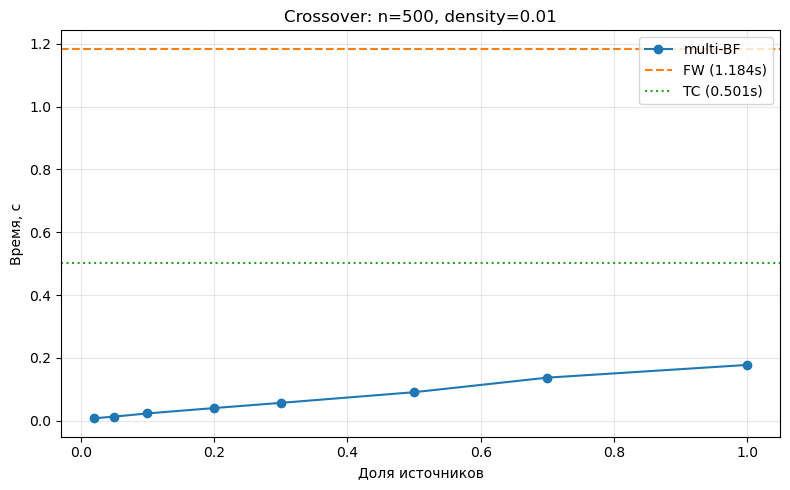

In [136]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(df_cross["source_frac"], df_cross["bf_multi_s"], "o-", label="multi-BF")
ax.axhline(fw_time, color="C1", linestyle="--", label=f"FW ({fw_time:.3f}s)")
ax.axhline(tc_time, color="C2", linestyle=":", label=f"TC ({tc_time:.3f}s)")
ax.set_xlabel("Доля источников")
ax.set_ylabel("Время, с")
ax.set_title(f"Crossover: n={CROSS_N}, density={CROSS_DENSITY}")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Задание 7 (+2 балла). Push/pull

`bellman_ford_direction`: pull, push или auto по наполненности вектора.


In [ ]:
def bellman_ford_direction(A: Matrix, source: int, mode: str = "pull", fill_threshold: float = 0.5) -> list:
    n = A.nrows
    AT = A.T.new()
    d = Vector(dtypes.FP64, size=n)
    d[source] = 0.0

    def relax(d_vec):
        if mode == "pull":
            d_vec(binary.min) << d_vec.vxm(A, semiring.min_plus)
        elif mode == "push":
            d_vec(binary.min) << AT.mxv(d_vec, semiring.min_plus)
        elif mode == "auto":
            if d_vec.nvals / n <= fill_threshold:
                d_vec(binary.min) << AT.mxv(d_vec, semiring.min_plus)
            else:
                d_vec(binary.min) << d_vec.vxm(A, semiring.min_plus)
        else:
            raise ValueError(mode)
        return d_vec

    for _ in range(n - 1):
        d_old = d.dup()
        relax(d)
        if d.isequal(d_old):
            break

    d_before = d.dup()
    relax(d)
    if not d.isequal(d_before):
        return bellman_ford(A, source)

    return [float(x) for x in d.to_dense(fill_value=float('inf'))]


`benchmark_directions`: замер pull, push и auto; результаты сверяются с `bellman_ford`.


In [ ]:
def benchmark_directions(A: Matrix, source: int = 0, n_runs: int = 5) -> pd.DataFrame:
    modes = [
        ("pull", {}),
        ("push", {}),
        ("auto_0.3", {"mode": "auto", "fill_threshold": 0.3}),
        ("auto_0.7", {"mode": "auto", "fill_threshold": 0.7}),
    ]
    rows = []
    ref = bellman_ford(A, source)
    for label, kwargs in modes:
        mode = kwargs.pop("mode", label.split("_")[0])
        if label.startswith("auto"):
            mode = "auto"
        elapsed = []
        for _ in range(n_runs):
            start = time.perf_counter()
            result = bellman_ford_direction(A, source, mode=mode, **kwargs)
            elapsed.append(time.perf_counter() - start)
        assert_distances_equal(result, ref, label)
        rows.append({"mode": label, "mean_s": np.mean(elapsed), "std_s": np.std(elapsed)})
    return pd.DataFrame(rows)


### Замер

$n=2000$, `density=0.01`, один источник.


In [138]:
G_dir = generate_random_weighted_graph(2000, 0.01, seed=99)
df_dir = benchmark_directions(G_dir, source=0, n_runs=3)
df_dir


,mode,mean_s,std_s
0,pull,0.002965,0.000207
1,push,0.004640,0.000065
2,auto_0.3,0.004618,0.000312
3,auto_0.7,0.004245,0.000077


### Выводы

1. **Размер** (`density=0.01`, 5 источников): `bf_multi` растёт слабо (≈0.0034 с при n=100 до ≈0.0066 с при n=600). `floyd_warshall` растёт резко (≈0.063 с → ≈2.34 с), `transitive_closure` быстрее FW (≈0.022 с → ≈0.80 с).

2. **Плотность** (n=400, 5 источников): `bf_multi` почти постоянен (≈0.003–0.004 с). FW растёт с плотностью (≈0.26 с при density=0.001 до ≈1.12 с при 0.05).

3. **Crossover** (n=500, density=0.01): multi-BF ниже горизонтальных линий FW и TC на всём диапазоне долей источников; пересечения нет.

4. **SuiteSparse** (связный подграф n=400, 10 источников): multi-BF ≈0.002–0.004 с; FW ≈0.81–0.97 с; TC ≈0.08–0.12 с. TC быстрее FW в ~8–10 раз; при 10 источниках multi-BF выгоднее all-pairs.

5. **Push/pull** (n=2000, density=0.01, 1 источник): pull быстрее push на разреженном frontier.
